Page size: (595.2000122070312, 841.6799926757812)
Width: 2976
Height: 4208


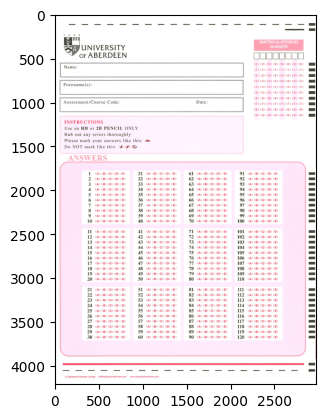

In [111]:
import cv2
import pypdfium2 as pdfium
import matplotlib.pyplot as plt
import numpy as np
import os

FILE = "example.pdf"
SCALE = 5.0

doc = pdfium.PdfDocument(FILE)
page = doc[0]
print("Page size:", doc.get_page_size(0))

width = int(doc.get_page_size(0)[0] * SCALE)
height = int(doc.get_page_size(0)[1] * SCALE)

print("Width:", width)
print("Height:", height)

image = page.render(scale = SCALE,no_smoothimage=True,optimize_mode="print")
image = image.to_numpy()

#read the FILE as a tiff image
#image = cv2.imread(FILE)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#show the image using matplotlib in its original size

plt.imshow(image)
plt.show()

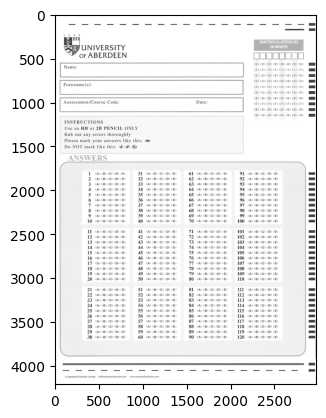

In [112]:
#make the image greyscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')

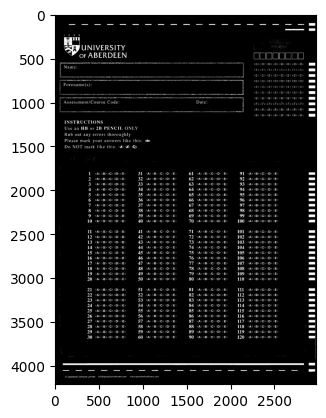

In [113]:
#threshold the image, setting anything above 40 to 255
_, thresh = cv2.threshold(gray, 160, 255, cv2.THRESH_BINARY)
thresh = cv2.bitwise_not(thresh)
plt.imshow(thresh, cmap='gray')

In [114]:
#detect horizontal line which should run above pixel 50 and below pixel 800 in the thresh image and draw it on the original image. Use the ransac algorithm to detect the line

#invert the image

linesTop = cv2.HoughLinesP(thresh[0:int(height*0.05)],1, np.pi/180, 100, minLineLength=5, maxLineGap=100) #N.B., 5% here
linesBottom = cv2.HoughLinesP(thresh[int(height-height*0.05):],1, np.pi/180, 100, minLineLength=5, maxLineGap=100)

lines = np.concatenate((linesTop, linesBottom))

#print(len(lines))
#for line in lines:
#    x1, y1, x2, y2 = line[0]
#    cv2.line(image, (x1, y1), (x2, y2), (0, 0, 0), 5)

#plt.imshow(image)



0.05405488405229563


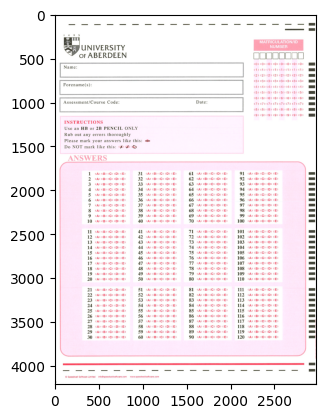

In [115]:
#get the average angle of all the lines and rotate the image to straighten the image
angles = []
for line in lines:
    x1, y1, x2, y2 = line[0]
    angle = np.arctan2(y2 - y1, x2 - x1) * 180 / np.pi
    angles.append(angle)

angle = np.mean(angles)
print(angle)

rotated = cv2.warpAffine(image, cv2.getRotationMatrix2D((image.shape[1]//2, image.shape[0]//2), angle, 1), (image.shape[1], image.shape[0]))

plt.imshow(rotated)

In [116]:
#we need to make the black bars properly black via thresholding
gray = cv2.cvtColor(rotated, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 160, 255, cv2.THRESH_BINARY)

#move down the 15h pixel along the right hand side and detect black bars, recording their start and finish points

foundTop = False

blackBars = []
for i in range(0,thresh.shape[0]):
    if thresh[i,int(-width*0.03)] == 0 and not foundTop: #N.B., 3% here
        foundTop = True
        top = i
    if thresh[i,int(-width*0.03)] == 255 and foundTop:
        foundTop = False
        blackBars.append((top, i))

#draw horizontal lines across the image along the centre of each black bar
#for b in blackBars:
#    middle = (b[0] + b[1]) // 2
#    line = np.array([[0, middle], [thresh.shape[1], middle]])
#    cv2.line(rotated, tuple(line[0]), tuple(line[1]), (0, 0, 255), 2)

#plt.imshow(rotated)
        

        

In [117]:
def ssd(a,b):
    return np.sum((a-b)**2)

In [121]:
#extract "template" symbol which we will use to find other symbols.
for i in range(2,12):
    line = rotated[blackBars[i][0]:blackBars[i][1], int(width*0.75):int(width*0.95)]
    line = cv2.cvtColor(line, cv2.COLOR_BGR2GRAY)
    line = cv2.threshold(line, 200, 255, cv2.THRESH_BINARY)[1]
    bwline = line.copy() #used later for writing the symbol
    
    #uncomment to generate symbols
    #symbol=rotated[blackBars[i][0]:blackBars[i][1], int(width*0.75)+26:int(width*0.75)+86]
    #symbol = cv2.cvtColor(symbol, cv2.COLOR_BGR2GRAY)
    #symbol = cv2.threshold(symbol, 200, 255, cv2.THRESH_BINARY)[1]
    
    #uncomment to use averaged symbols from pregenerated data
    symbol = cv2.imread(f"{str(i-2)}/average_symbol.png",0)
    symbol = cv2.threshold(symbol, 220, 255, cv2.THRESH_BINARY)[1]

    kernel = np.ones((3,3),np.uint8)
    
    symbol = cv2.erode(symbol,kernel,iterations = 2)
    line = cv2.erode(line,kernel,iterations = 2)

    #plt.imshow(line, cmap='gray')
    #plt.show()
    #plt.imshow(symbol, cmap='gray')
    #plt.show()

    ssd_values = np.zeros([line.shape[1]])
    ssd_values.fill(1000)
    for x in range(symbol.shape[1]//2,1+((line.shape[1]-symbol.shape[1]//2))):
        patch = line[:,x-symbol.shape[1]//2:x+symbol.shape[1]//2]
        ssd_values[x] = ssd(patch,symbol)

    #print(ssd_values)
    
    #ssd_values now contains the ssd values for each position of the symbol in the line.

    #find optimal ssd values which will give us 8 non-zero values
    centres = []
    for pos_thresh in range(500,1,-1):
        centres = []
        #set new_ssd_values to 0 if the ssd value is below the threshold, and the value otherwise
        new_ssd_values = np.where(ssd_values < pos_thresh, 0, 1)
        found_start = False
        start_pos = 0
        for x in range(len(new_ssd_values)):
            if new_ssd_values[x] == 0 and not found_start:
                found_start = True
                start_pos = x
            if new_ssd_values[x] != 0 and found_start:
                found_start = False
                centres.append((start_pos+x)//2)
        if len(centres) == 8:
            break
    print(centres)
    
    #so now we have the centres of each symbol. We want to write the symbol at each centre on the original line to the file. We want to put each one in a directory "i-2" as we are starting from 2.
    #if not os.path.exists(str(i-2)):
    #    os.mkdir(str(i-2))
    #average_symbol = np.zeros([symbol.shape[0],symbol.shape[1]])
    #for x in centres:
    #    symbol2 = bwline[:,x-symbol.shape[1]//2:x+symbol.shape[1]//2]
    #    average_symbol += symbol2
    #    cv2.imwrite(f"{str(i-2)}/symbol"+str(i)+str(x)+".png",symbol2)
    #    cv2.line(rotated, (int(width*0.75)+x-symbol2.shape[1]//2, blackBars[i][0]), (int(width*0.75)+x-symbol2.shape[1]//2, blackBars[i][1]), (0, 0, 255), 2)
    #average_symbol = average_symbol / 8
    #cv2.imwrite(f"{str(i-2)}/average_symbol.png",average_symbol)

        
                       


[56, 128, 201, 273, 345, 417, 489, 560]
[57, 128, 201, 273, 345, 418, 490, 561]
[56, 128, 201, 273, 345, 418, 489, 560]
[56, 128, 201, 273, 345, 417, 489, 561]
[56, 128, 201, 273, 345, 418, 489, 560]
[56, 128, 201, 273, 345, 417, 489, 560]
[56, 128, 201, 273, 345, 417, 489, 560]
[56, 128, 201, 273, 345, 417, 489, 560]
[56, 128, 201, 273, 345, 417, 489, 560]
[56, 128, 201, 273, 345, 417, 489, 560]


[[0.8770955  0.8740856  0.87034917 ... 0.9058055  0.8948857  0.88425964]
 [0.89715654 0.8945471  0.8913681  ... 0.9058056  0.89490366 0.8842778 ]
 [0.9011921  0.89894015 0.89627403 ... 0.90580547 0.8949212  0.8842954 ]
 ...
 [0.87519854 0.88677645 0.8977212  ... 0.9058319  0.90581834 0.90585345]
 [0.87540364 0.88697076 0.89792246 ... 0.90117836 0.9011439  0.90117204]
 [0.8755152  0.8870753  0.89805055 ... 0.8800258  0.8799911  0.8800214 ]]


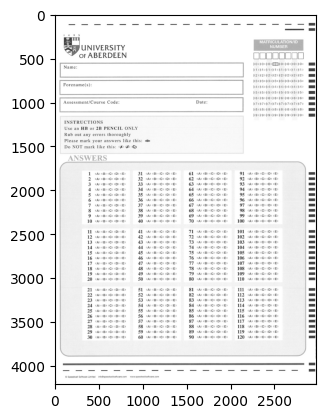

[[0.9058933  0.90348613 0.89998    ... 0.9310573  0.9211177  0.9105194 ]
 [0.9239927  0.9218926  0.91891575 ... 0.9310575  0.92113495 0.91053677]
 [0.92724496 0.9254324  0.92294705 ... 0.9310573  0.92115164 0.91055363]
 ...
 [0.9039314  0.91450995 0.92448664 ... 0.93108493 0.9310949  0.9311112 ]
 [0.90413    0.91470516 0.92469513 ... 0.9272188  0.9272126  0.9272148 ]
 [0.9042235  0.914808   0.92481744 ... 0.90794563 0.9079395  0.9079407 ]]


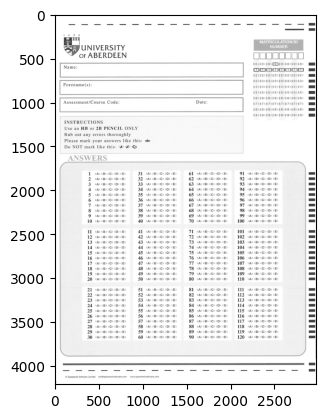

In [75]:
from tqdm import tqdm

symbols = []
for i in range(10):
    symbol = cv2.imread(f"{str(i)}/average_symbol.png")
    symbol = cv2.cvtColor(symbol, cv2.COLOR_BGR2GRAY)
    symbols.append(symbol)

out = cv2.cvtColor(rotated, cv2.COLOR_BGR2GRAY)
#out = cv2.threshold(out, 160, 255, cv2.THRESH_BINARY)[1]

#for each of the lines we want to find the symbols in the line and display them
for i in range(2,12):
    line = rotated[blackBars[i][0]:blackBars[i][1], int(width*0.75):int(width*0.95)]
    line = cv2.cvtColor(line, cv2.COLOR_BGR2GRAY)
    line = cv2.threshold(line, 200, 255, cv2.THRESH_BINARY)[1]

    





(33, 595, 3)
(33, 60, 3)


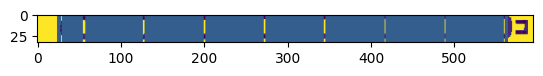

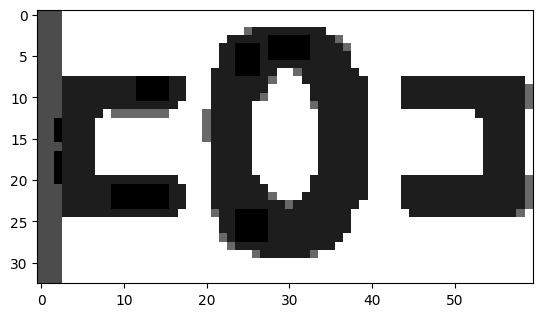

26
98
171
243
315
387
459
530
(33, 595, 3)
(33, 60, 3)


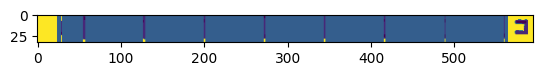

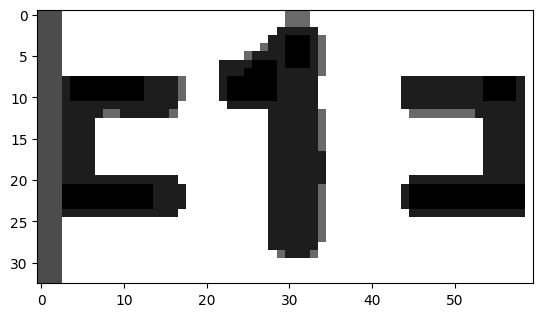

26
98
171
243
315
387
459
530
(31, 595, 3)
(31, 60, 3)


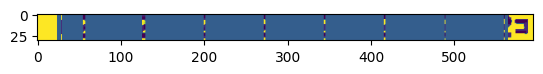

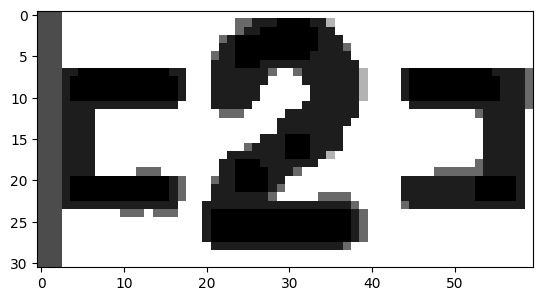

26
98
171
243
315
387
459
530
(32, 595, 3)
(32, 60, 3)


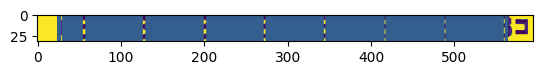

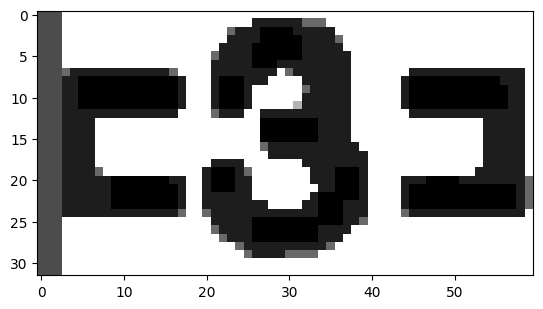

26
98
171
243
315
387
459
530
(32, 595, 3)
(32, 60, 3)


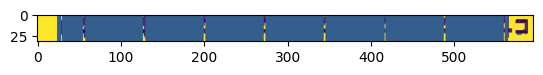

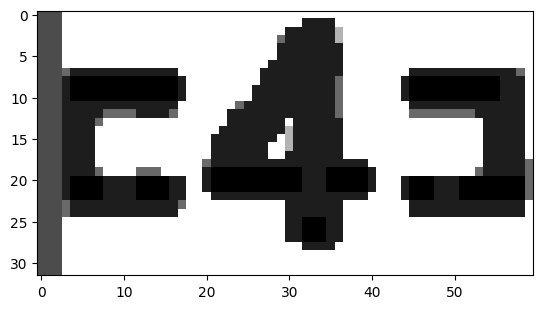

26
98
171
243
315
387
459
530
(33, 595, 3)
(33, 60, 3)


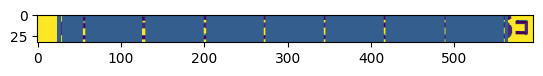

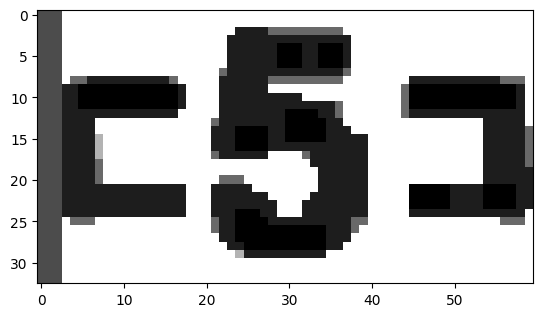

26
98
171
243
315
387
459
530
(33, 595, 3)
(33, 60, 3)


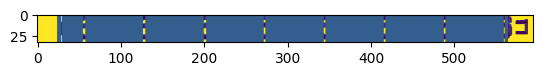

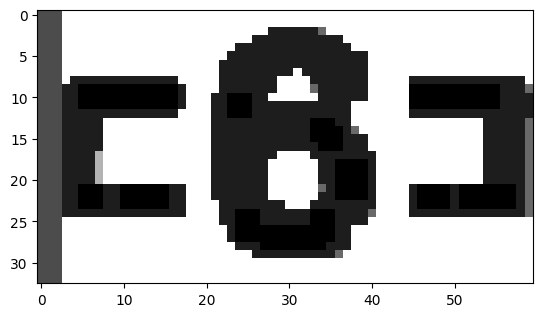

26
98
171
243
315
387
459
530
(32, 595, 3)
(32, 60, 3)


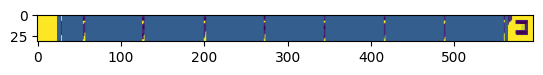

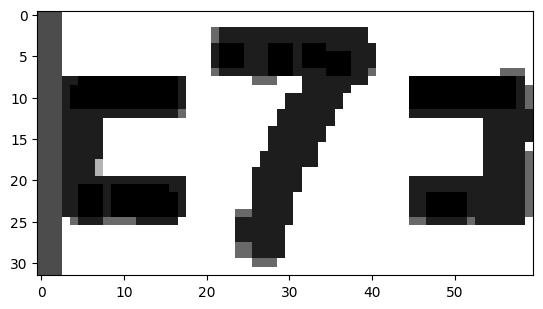

26
97
171
243
315
387
459
530
(32, 595, 3)
(32, 60, 3)


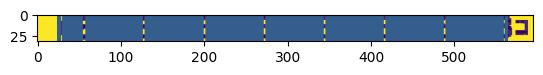

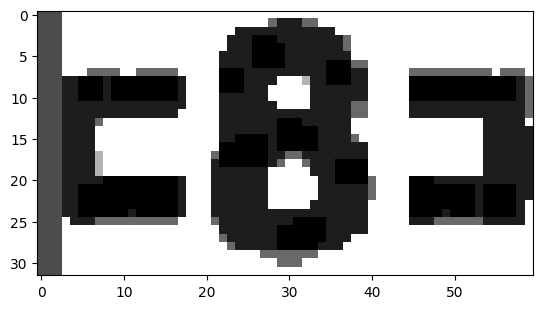

26
98
171
243
315
387
459
530
(33, 595, 3)
(33, 60, 3)


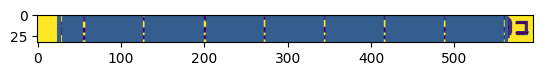

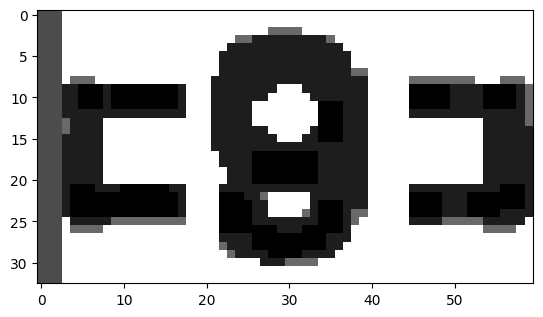

26
98
171
243
315
387
459
530
61


In [38]:
best_j=0 #this is the threshold for ssd
for i in range(2,12):
    line = rotated[blackBars[i][0]:blackBars[i][1], int(width*0.75):int(width*0.95)]
    line = cv2.threshold(line, 200, 255, cv2.THRESH_BINARY)[1]
    print(line.shape)
    symbol=rotated[blackBars[i][0]:blackBars[i][1], int(width*0.75)+26:int(width*0.75)+86]
    symbol = cv2.threshold(symbol, 200, 255, cv2.THRESH_BINARY)[1]
    print(symbol.shape)

    #erode the symbol to make it more distinct
    kernel = np.ones((3,3), np.uint8)
    symbol = cv2.erode(symbol, kernel, iterations=1)

    #do the same for line
    line = cv2.erode(line, kernel, iterations=1)

    #now do a sum of squared differences between the line and the symbol
    #this will give us the best match
    
    ssd_values = []
    for x in range(symbol.shape[1]//2, 1+((line.shape[1]-symbol.shape[1]//2))):
        ssd = np.sum((line[:, (x-symbol.shape[1]//2):(x+symbol.shape[1]//2)] - symbol)**2)
        ssd_values.append(ssd)
        
    
    #normalise the ssd values to be between 0 and 1
    ssd_values = np.array(ssd_values)
    ssd_values = (ssd_values - np.min(ssd_values)) / (np.max(ssd_values) - np.min(ssd_values))
    ssd_values *=255
    
    
    #check all ssd_values between 1 and 255 such that we have a total of 8 sequences of 0s. We wan the lowest ssd_value for this.
    for j in range(1, 255):
        #look for 8 sequences of 0s
        num_found = 0
        found = False
        start = 0
        for x in range(0, len(ssd_values)):
            if ssd_values[x] <= j and not found:
                start = x
                found = True
            if ssd_values[x] > j and found:
                found = False
                num_found+=1

        if num_found == 8:
            break

    if best_j < j:
        best_j = j  

    ssd_values[ssd_values<best_j] = 0
    #print(ssd_values)

    #draw the ssd values on the line
    for x in range(symbol.shape[1]//2, ((line.shape[1]-symbol.shape[1]//2))):
        cv2.line(line, (x, 0), (x, int(ssd_values[x-symbol.shape[1]//2])), (0, 0, 255), 1)
    
    #make it greyscale
    line = cv2.cvtColor(line, cv2.COLOR_BGR2GRAY)
    symbol = cv2.cvtColor(symbol, cv2.COLOR_BGR2GRAY)
    plt.imshow(line)
    plt.show()
    plt.imshow(symbol, cmap='gray')
    plt.show()
    #print out the x coordinate of the minimum value of ssd_values, where a sequence of 0s returns only the central point
    found = False
    start = 0
    for x in range(0, len(ssd_values)):
        if ssd_values[x] == 0 and not found:
            start = x
            found = True
        if ssd_values[x] != 0 and found:
            found = False
            print(start + (x-start)//2)
    

print(best_j)

    

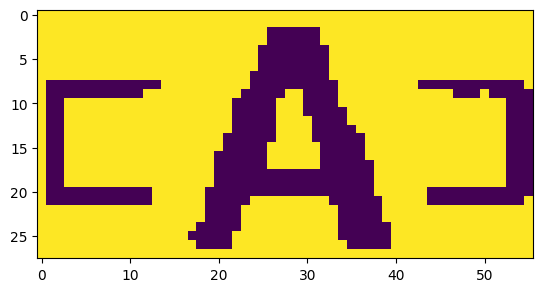

In [8]:
#Elements 2-11 are the matriculation number (inclusive)
#Elements 12-41 inclusive are the answers

#for the matriculation number, show the righthand most 75-95% of the image
for i in range(12,42):
    line = rotated[blackBars[i][0]:blackBars[i][1], 0:int(width*0.95)]
    #make grayscale
    line = cv2.cvtColor(line, cv2.COLOR_BGR2GRAY)
    #threshold
    line = cv2.threshold(line, 160, 255, cv2.THRESH_BINARY)[1]
    symbol = line[:,71+int(line.shape[1]*0.75):127+int(line.shape[1]*0.75)]
    plt.imshow(symbol)


In [13]:
best_j=0 #this is the threshold for ssd
for i in range(2,12):
    line = rotated[blackBars[i][0]:blackBars[i][1], int(width*0.75):int(width*0.95)]
    line = cv2.threshold(line, 200, 255, cv2.THRESH_BINARY)[1]
    print(line.shape)
    symbol=rotated[blackBars[i][0]:blackBars[i][1], int(width*0.75)+26:int(width*0.75)+86]
    symbol = cv2.threshold(symbol, 200, 255, cv2.THRESH_BINARY)[1]
    print(symbol.shape)

    #erode the symbol to make it more distinct
    kernel = np.ones((3,3), np.uint8)
    symbol = cv2.erode(symbol, kernel, iterations=1)

    #do the same for line
    line = cv2.erode(line, kernel, iterations=1)

    #now do a sum of squared differences between the line and the symbol
    #this will give us the best match
    
    ssd_values = []
    for x in range(symbol.shape[1]//2, 1+((line.shape[1]-symbol.shape[1]//2))):
        ssd = np.sum((line[:, (x-symbol.shape[1]//2):(x+symbol.shape[1]//2)] - symbol)**2)
        ssd_values.append(ssd)
        
    
    #normalise the ssd values to be between 0 and 1
    ssd_values = np.array(ssd_values)
    ssd_values = (ssd_values - np.min(ssd_values)) / (np.max(ssd_values) - np.min(ssd_values))
    ssd_values *=255
    
    
    #check all ssd_values between 1 and 255 such that we have a total of 8 sequences of 0s. We wan the lowest ssd_value for this.
    for j in range(1, 255):
        #look for 8 sequences of 0s
        num_found = 0
        found = False
        start = 0
        for x in range(0, len(ssd_values)):
            if ssd_values[x] <= j and not found:
                start = x
                found = True
            if ssd_values[x] > j and found:
                found = False
                num_found+=1

        if num_found == 8:
            break

    if best_j < j:
        best_j = j  

    ssd_values[ssd_values<best_j] = 0
    #print(ssd_values)

    for j in range(0, len(ssd_values)):
        if ssd_values[j]>0:
            print(i,j,ssd_values[j])
            #smb = line[:, (i-symbol.shape[1]//2):(i+symbol.shape[1]//2)]
            #plt.imshow(smb)
            #plt.show()


(33, 595, 3)
(33, 60, 3)
2 0 246.2888198757764
2 1 246.2888198757764
2 2 240.2173913043478
2 3 230.05434782608697
2 4 224.11490683229815
2 5 219.36335403726707
2 6 215.667701863354
2 7 212.7639751552795
2 8 218.57142857142856
2 9 227.0186335403727
2 10 233.88198757763976
2 11 234.40993788819875
2 12 227.54658385093168
2 13 216.72360248447205
2 14 207.74844720496895
2 15 203.7888198757764
2 16 204.8447204968944
2 17 209.59627329192548
2 18 214.3478260869565
2 19 211.97204968944098
2 20 203.7888198757764
2 21 189.79813664596276
2 22 161.8167701863354
2 23 126.44409937888199
2 24 86.05590062111801
2 28 91.33540372670807
2 29 133.30745341614906
2 30 168.6801242236025
2 31 196.66149068322983
2 32 210.65217391304347
2 33 216.98757763975158
2 34 219.09937888198758
2 35 214.3478260869565
2 36 209.06832298136646
2 37 207.48447204968943
2 38 210.916149068323
2 39 218.96739130434784
2 40 228.8664596273292
2 41 237.18167701863354
2 42 231.9021739130435
2 43 218.83540372670808
2 44 205.108695652173

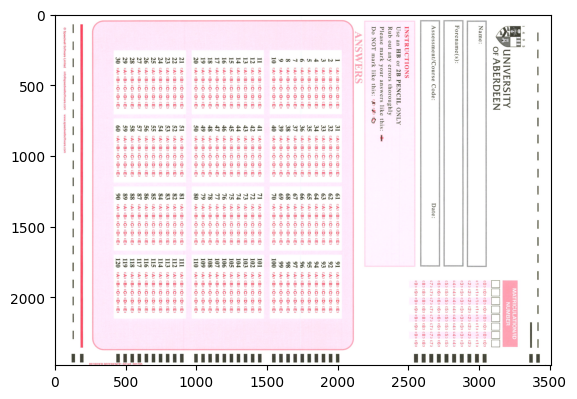

In [31]:
#bb is a bytesIO containing a png, read and draw it
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io
import numpy as np
import cv2
import PIL

bb.seek(0)
img = PIL.Image.open(bb)
img = np.array(img)
plt.imshow(img)
plt.show()

In [30]:
bb